# Reintegration Readiness Classifier

This notebook builds a **case management pipeline** for the INTEX IS 455 requirement. The pipeline is designed to help staff identify which residents appear most ready for **reintegration planning within the next 180 days**, while also surfacing the relationships behind that prediction.

This notebook is intentionally structured to match the required assignment sections:

1. Problem Framing  
2. Data Acquisition, Preparation & Exploration  
3. Modeling & Feature Selection  
4. Evaluation & Interpretation  
5. Causal and Relationship Analysis  
6. Deployment Notes

The implementation follows the textbook emphasis on:
- **prediction vs. explanation**
- **reproducible data preparation pipelines**
- **dummy coding / one-hot encoding where appropriate**
- **thoughtful feature selection**
- **proper validation**
- **deployment as part of the pipeline, not an afterthought**

## 1. Problem Framing

### Business question
Which residents appear most likely to become **reintegration-ready within the next 180 days**, based on their counseling activity, home visitation history, education progress, health and wellbeing records, intervention plans, and incident history?

### Who cares about this?
This pipeline is most useful for:
- **admin and case-management staff** who need a queue of residents to review for reintegration planning
- **social workers** who need to prioritize case conferences, family follow-up, and transition planning
- **leadership** who need aggregated insight into case progress across safehouses

### Why this matters
The case-management side of the project is not just about storing records. The organization needs a way to understand which girls are progressing, which girls may need more support, and when reintegration planning should begin. A readiness score can help staff focus limited time on the residents most likely to benefit from the next step in the case lifecycle.

### Predictive vs. explanatory choice
This notebook is **primarily predictive** because the organization needs an operational output that can be placed in an admin dashboard or case-review queue. That said, this notebook also includes a **relationship analysis** section so the patterns behind the model can be interpreted carefully.

### Target used in this notebook
Because the synthetic dataset does not provide a single ready-made `reintegration_ready` label at every time point, this notebook engineers a forward-looking target:

- `ready_within_180d = 1` if a resident has a `date_closed` within the next 180 days **and** has a non-null `reintegration_type`
- `ready_within_180d = 0` otherwise

This is a proxy for reintegration readiness. It is useful, but it is not a perfect causal truth. That limitation is discussed later in the notebook.

In [ ]:
# Imports, configuration, and helper functions

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.feature_selection import SelectFromModel
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, RandomizedSearchCV
    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
        confusion_matrix,
        classification_report,
        RocCurveDisplay,
        PrecisionRecallDisplay
    )
    from sklearn.inspection import permutation_importance
except ImportError as exc:
    raise ImportError(
        "Missing required Python packages. Install them in the active Python environment with: "
        "python -m pip install scikit-learn pandas matplotlib"
    ) from exc

warnings.filterwarnings("ignore")

# Configuration constants
SEED = 27
PREDICTION_WINDOW_DAYS = 180
ANALYSIS_CUTOFF = pd.Timestamp("2026-04-06")

# List of potential data directory paths to search for CSV files
DATA_DIR_CANDIDATES = [
    Path("../data"),
    Path("./data"),
    Path("/mnt/batch/tasks/shared/LS_root/mounts/clusters/notebookdev/code/data"),
    Path("../lighthouse_csv_v7"),
    Path("./lighthouse_csv_v7"),
]

# Define the output directory for generated results
OUTPUT_DIR = Path("../generated_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def resolve_data_dir(candidates):
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*.csv")):
            return candidate
    # Loop through subdirectories if no direct match found    
    for candidate in candidates:
        if candidate.exists():
            for sub in candidate.iterdir():
                if sub.is_dir() and any(sub.glob("*.csv")):
                    return sub
     # If no valid directory found, raise an error with helpful message
    raise FileNotFoundError(
        "Could not find a data folder containing CSV files. Checked: "
        + ", ".join(str(p.resolve()) for p in candidates)
    )

# Resolve and set the actual data directory from candidates
DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)

REQUIRED_FILES = {
    "residents": DATA_DIR / "residents.csv",
    "process_recordings": DATA_DIR / "process_recordings.csv",
    "home_visitations": DATA_DIR / "home_visitations.csv",
    "education_records": DATA_DIR / "education_records.csv",
    "health_wellbeing_records": DATA_DIR / "health_wellbeing_records.csv",
    "intervention_plans": DATA_DIR / "intervention_plans.csv",
    "incident_reports": DATA_DIR / "incident_reports.csv",
    "safehouses": DATA_DIR / "safehouses.csv",
}

print("Working directory:", Path.cwd())
print("Resolved data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

def assert_required_files_exist(required_files):
    missing = [name for name, path in required_files.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing required CSV files: {missing}. Expected them under: {DATA_DIR.resolve()}"
        )

def load_csv_safe(path, parse_dates=None):
    if not Path(path).exists():
        raise FileNotFoundError(f"Could not find file: {path}")
    try:
         # If date columns are specified, parse them as datetime
        df = pd.read_csv(path)
        if parse_dates:
            for col in parse_dates:
                if col in df.columns:
                    df[col] = pd.to_datetime(df[col], errors="coerce")
        return df
    except Exception as exc:
        raise RuntimeError(f"Failed to load CSV at {path}: {exc}") from exc

def validate_required_columns(df, table_name, required_columns):
    # Find which required columns are missing from the DataFrame
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Table '{table_name}' is missing required columns: {missing}")

assert_required_files_exist(REQUIRED_FILES)

Working directory: c:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines
Resolved data directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\lighthouse_csv_v7\lighthouse_csv_v7
Output directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs


## 2. Data Acquisition, Preparation & Exploration

This section loads the core case-management tables and prepares them for feature engineering. The joins and aggregations are designed to be **reproducible**, following the textbook guidance to build a data preparation pipeline rather than a one-off script.

### Tables used
- `residents`
- `process_recordings`
- `home_visitations`
- `education_records`
- `health_wellbeing_records`
- `intervention_plans`
- `incident_reports`
- `safehouses`

### Why these tables?
Together, these tables cover the resident lifecycle from intake and case context through counseling, health, education, visits, incidents, and intervention planning. That makes them the strongest set for a case-management pipeline.

In [ ]:
# Load tables and parse date fields

residents = load_csv_safe(
    REQUIRED_FILES["residents"],
    parse_dates=[
        "date_of_birth",
        "date_of_admission",
        "date_colb_registered",
        "date_colb_obtained",
        "date_case_study_prepared",
        "date_enrolled",
        "date_closed",
        "created_at"
    ]
)

process_recordings = load_csv_safe(
    REQUIRED_FILES["process_recordings"],
    parse_dates=["session_date"]
)

home_visitations = load_csv_safe(
    REQUIRED_FILES["home_visitations"],
    parse_dates=["visit_date"]
)

education_records = load_csv_safe(
    REQUIRED_FILES["education_records"],
    parse_dates=["record_date"]
)

health_records = load_csv_safe(
    REQUIRED_FILES["health_wellbeing_records"],
    parse_dates=["record_date"]
)

intervention_plans = load_csv_safe(
    REQUIRED_FILES["intervention_plans"],
    parse_dates=["target_date", "case_conference_date", "created_at", "updated_at"]
)

incident_reports = load_csv_safe(
    REQUIRED_FILES["incident_reports"],
    parse_dates=["incident_date", "resolution_date"]
)

safehouses = load_csv_safe(
    REQUIRED_FILES["safehouses"],
    parse_dates=["open_date"]
)

## parse data fields 
validate_required_columns(
    residents,
    "residents",
    [
        "resident_id", "safehouse_id", "date_of_admission",
        "initial_risk_level", "case_status", "reintegration_type"
    ]
)

validate_required_columns(
    process_recordings,
    "process_recordings",
    ["resident_id", "session_date", "session_duration_minutes", "session_type", "emotional_state_end"]
)

validate_required_columns(
    home_visitations,
    "home_visitations",
    ["resident_id", "visit_date", "visit_type", "location_visited"]
)

validate_required_columns(
    education_records,
    "education_records",
    ["resident_id", "record_date", "attendance_rate", "progress_percent", "completion_status"]
)

validate_required_columns(
    health_records,
    "health_wellbeing_records",
    [
        "resident_id", "record_date", "general_health_score",
        "nutrition_score", "sleep_quality_score", "energy_level_score"
    ]
)

validate_required_columns(
    intervention_plans,
    "intervention_plans",
    ["resident_id", "plan_category", "status", "case_conference_date"]
)

validate_required_columns(
    incident_reports,
    "incident_reports",
    ["resident_id", "incident_date", "incident_type", "severity", "follow_up_required"]
)

validate_required_columns(
    safehouses,
    "safehouses",
    ["safehouse_id", "name", "region"]
)

# Create occupancy_rate if it is not already stored
if "occupancy_rate" not in safehouses.columns:
    if {"current_occupancy", "capacity_girls"}.issubset(safehouses.columns):
        safehouses["occupancy_rate"] = np.where(
            safehouses["capacity_girls"].fillna(0) > 0,
            safehouses["current_occupancy"] / safehouses["capacity_girls"],
            np.nan
        )
    else:
        safehouses["occupancy_rate"] = np.nan
        
print("residents:", residents.shape)
print("process_recordings:", process_recordings.shape)
print("home_visitations:", home_visitations.shape)
print("education_records:", education_records.shape)
print("health_records:", health_records.shape)
print("intervention_plans:", intervention_plans.shape)
print("incident_reports:", incident_reports.shape)
print("safehouses:", safehouses.shape)

residents: (60, 49)
process_recordings: (2819, 15)
home_visitations: (1337, 14)
education_records: (534, 10)
health_records: (534, 14)
intervention_plans: (180, 11)
incident_reports: (100, 12)
safehouses: (9, 14)


In [ ]:
# Filter out future-dated records beyond the analysis cutoff.
# The uploaded EDA report noted future-dated rows in several case tables,
# so this keeps the training data historical and avoids leaking future events.

def filter_to_cutoff(df, date_cols, cutoff):
    df = df.copy()
    # Loop through each date column that needs to be filtered
    for col in date_cols:
        if col in df.columns:
            df = df[(df[col].isna()) | (df[col] <= cutoff)]
    return df

# Filter residents table by date_admission, date_closed, and created_at
residents = filter_to_cutoff(
    residents,
    ["date_of_admission", "date_closed", "created_at"],
    ANALYSIS_CUTOFF
)

# Filter process_recordings by session_date
process_recordings = filter_to_cutoff(process_recordings, ["session_date"], ANALYSIS_CUTOFF)
home_visitations = filter_to_cutoff(home_visitations, ["visit_date"], ANALYSIS_CUTOFF)
education_records = filter_to_cutoff(education_records, ["record_date"], ANALYSIS_CUTOFF)
health_records = filter_to_cutoff(health_records, ["record_date"], ANALYSIS_CUTOFF)
intervention_plans = filter_to_cutoff(
    intervention_plans,
    ["target_date", "case_conference_date", "created_at", "updated_at"],
    ANALYSIS_CUTOFF
)
incident_reports = filter_to_cutoff(incident_reports, ["incident_date", "resolution_date"], ANALYSIS_CUTOFF)

print("Rows after cutoff filtering")
print("residents:", residents.shape)
print("process_recordings:", process_recordings.shape)
print("home_visitations:", home_visitations.shape)
print("education_records:", education_records.shape)
print("health_records:", health_records.shape)
print("intervention_plans:", intervention_plans.shape)
print("incident_reports:", incident_reports.shape)

Rows after cutoff filtering
residents: (56, 49)
process_recordings: (2763, 15)
home_visitations: (1290, 14)
education_records: (534, 10)
health_records: (534, 14)
intervention_plans: (180, 11)
incident_reports: (99, 12)


In [ ]:
# Quick structural checks

# Create a summary dataframe showing the structure of all loaded tables
summary_df = pd.DataFrame({
    "table": [
        "residents", "process_recordings", "home_visitations", "education_records",
        "health_records", "intervention_plans", "incident_reports", "safehouses"
    ],
    "rows": [
        len(residents), len(process_recordings), len(home_visitations), len(education_records),
        len(health_records), len(intervention_plans), len(incident_reports), len(safehouses)
    ],
    "cols": [
        residents.shape[1], process_recordings.shape[1], home_visitations.shape[1],
        education_records.shape[1], health_records.shape[1], intervention_plans.shape[1],
        incident_reports.shape[1], safehouses.shape[1]
    ]
})
summary_df

,table,rows,cols
0,residents,56,49
1,process_recordings,2763,15
2,home_visitations,1290,14
3,education_records,534,10
4,health_records,534,14
5,intervention_plans,180,11
6,incident_reports,99,12
7,safehouses,9,14


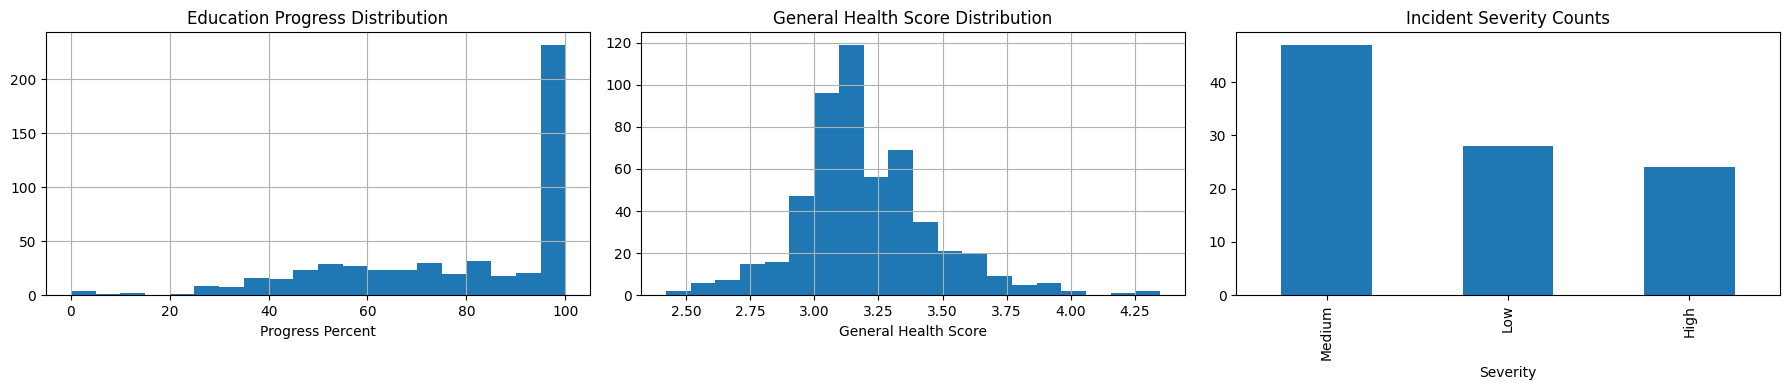

Residents with lower current risk than intake risk: 0.446
Average process recordings per resident: 46.05
Average home visitations per resident: 22.24


In [ ]:
# Normalize resident risk columns and print exploratory summaries

risk_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Critical": 4,
}


def safe_risk_num(series):
    return series.map(risk_mapping).astype(float)


if "initial_risk_num" not in residents.columns:
    if "initial_risk_level" in residents.columns:
        residents["initial_risk_num"] = safe_risk_num(residents["initial_risk_level"])
    else:
        residents["initial_risk_num"] = np.nan

if "current_risk_num" not in residents.columns:
    if "current_risk_level" in residents.columns:
        residents["current_risk_num"] = safe_risk_num(residents["current_risk_level"])
    else:
        residents["current_risk_num"] = np.nan

print(
    "Residents with lower current risk than intake risk:",
    (residents["current_risk_num"] < residents["initial_risk_num"]).mean().round(3),
)
print(
    "Average process recordings per resident:",
    process_recordings.groupby("resident_id").size().mean().round(2),
)
print(
    "Average home visitations per resident:",
    home_visitations.groupby("resident_id").size().mean().round(2),
)


### Snapshot design

A real predictive case-management pipeline should not use future information to predict the present. To keep the setup honest, this notebook creates **resident snapshot rows**. Each snapshot represents what the organization would know about a resident at a particular point in time.

For each snapshot:
- features are built using only information available on or before that date
- the label checks whether the resident reaches a reintegration-related closure in the **next 180 days**

This approach is more realistic than predicting from a final snapshot alone.

In [ ]:
# Feature engineering helpers
risk_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}

def safe_risk_num(series):
    return series.map(risk_map).fillna(pd.to_numeric(series, errors="coerce"))


# Create initial_risk_num column if it doesn't exist
if "initial_risk_num" not in residents.columns:
    residents["initial_risk_num"] = safe_risk_num(residents["initial_risk_level"])
else:
    residents["initial_risk_num"] = residents["initial_risk_num"].fillna(
        safe_risk_num(residents["initial_risk_level"])
    )


# Create current_risk_num column if current_risk_level exists
if "current_risk_level" in residents.columns:
    if "current_risk_num" not in residents.columns:
        residents["current_risk_num"] = safe_risk_num(residents["current_risk_level"])
    else:
        residents["current_risk_num"] = residents["current_risk_num"].fillna(
            safe_risk_num(residents["current_risk_level"]))

# Convert to end of month by going to next month and subtracting 1 day, then normalize
def month_end(date_value):
    if pd.isna(date_value):
        return pd.NaT
    return pd.Timestamp(date_value).to_period("M").to_timestamp("M")

def build_snapshot_dates(admission_date, close_date, analysis_cutoff, min_days_active=30, label_window_days=180):
    if pd.isna(admission_date):
        return []

    # Calculate the start date (admission + minimum active days required)
    start_date = admission_date + pd.Timedelta(days=min_days_active)
    final_observable_date = analysis_cutoff - pd.Timedelta(days=label_window_days)

    # If close_date exists, limit final observable date to one day before closing
    if pd.notna(close_date):
        final_observable_date = min(final_observable_date, close_date - pd.Timedelta(days=1))

    if start_date > final_observable_date:
        return []

    # Get month-end dates for start and final observable dates
    start_month_end = month_end(start_date)
    end_month_end = month_end(final_observable_date)

     # Return empty list if either month-end is missing or invalid range
    if pd.isna(start_month_end) or pd.isna(end_month_end) or start_month_end > end_month_end:
        return []

    return list(pd.date_range(start=start_month_end, end=end_month_end, freq="M"))

def get_recent_count(df, resident_id, date_col, snapshot_date, window_days):
    subset = df[df["resident_id"] == resident_id]
    # Calculate the start of the lookback window
    start_date = snapshot_date - pd.Timedelta(days=window_days)
    return int(((subset[date_col] > start_date) & (subset[date_col] <= snapshot_date)).sum())

def get_latest_row(df, resident_id, date_col, snapshot_date):
    subset = df[(df["resident_id"] == resident_id) & (df[date_col] <= snapshot_date)].sort_values(date_col)
     # Filter to this resident's records on or before snapshot date, sorted by date
    if subset.empty:
        return None
    return subset.iloc[-1]

def get_mean_recent(df, resident_id, date_col, value_col, snapshot_date, window_days):
    subset = df[df["resident_id"] == resident_id]
     # Calculate the start of the lookback window
    start_date = snapshot_date - pd.Timedelta(days=window_days)
    subset = subset[(subset[date_col] > start_date) & (subset[date_col] <= snapshot_date)]
    if subset.empty:
        return np.nan
    return subset[value_col].mean()

def build_case_snapshots(
    residents_df,
    process_df,
    visit_df,
    edu_df,
    health_df,
    plans_df,
    incidents_df,
    analysis_cutoff,
    prediction_window_days=180
):  # Initialize empty list to store all snapshot rows
    rows = []

 # Loop through each resident in the residents dataframe
    for _, resident in residents_df.iterrows():
        resident_id = resident["resident_id"]
        admission_date = resident["date_of_admission"]
        close_date = resident.get("date_closed", pd.NaT)

        snapshot_dates = build_snapshot_dates(
            admission_date=admission_date,
            close_date=close_date,
            analysis_cutoff=analysis_cutoff,
            min_days_active=30,
            label_window_days=prediction_window_days
        )
# Generate all monthly snapshot dates for this resident's active period
        
        for snapshot_date in snapshot_dates:
            future_window_end = snapshot_date + pd.Timedelta(days=prediction_window_days)
            ready_within_window = int(
                pd.notna(close_date)
                and pd.notna(resident.get("reintegration_type"))
                and snapshot_date < close_date <= future_window_end
            )
 # Get the most recent education record before snapshot date
            
            latest_edu = get_latest_row(edu_df, resident_id, "record_date", snapshot_date)
            latest_health = get_latest_row(health_df, resident_id, "record_date", snapshot_date)

# Filter process recordings for this resident in the 90-day lookback window
            
            process_90 = process_df[
                (process_df["resident_id"] == resident_id)
                & (process_df["session_date"] > snapshot_date - pd.Timedelta(days=90))
                & (process_df["session_date"] <= snapshot_date)
            ]

# Filter home visits for this resident in the 180-day lookback window
            
            visits_180 = visit_df[
                (visit_df["resident_id"] == resident_id)
                & (visit_df["visit_date"] > snapshot_date - pd.Timedelta(days=180))
                & (visit_df["visit_date"] <= snapshot_date)
            ]

# Filter incidents for this resident in the 180-day lookback window
            
            incidents_180 = incidents_df[
                (incidents_df["resident_id"] == resident_id)
                & (incidents_df["incident_date"] > snapshot_date - pd.Timedelta(days=180))
                & (incidents_df["incident_date"] <= snapshot_date)
            ]

            plans_hist = plans_df[
                (plans_df["resident_id"] == resident_id)
                & (plans_df["created_at"] <= snapshot_date)
            ]
             # Build the feature row for this snapshot
            row = {
                "resident_id": resident_id,
                "snapshot_date": snapshot_date,
                "ready_within_180d": ready_within_window,
                "safehouse_id": resident["safehouse_id"],
                "safehouse_region": resident.get("region"),
                "safehouse_occupancy_rate": resident.get("occupancy_rate"),
                "initial_risk_num": resident.get("initial_risk_num"),
                "case_status": resident.get("case_status"),
                "reintegration_type_current": resident.get("reintegration_type"),
                "days_since_admission": (snapshot_date - admission_date).days if pd.notna(admission_date) else np.nan,
                "age_years": ((snapshot_date - resident["date_of_birth"]).days / 365.25) if pd.notna(resident.get("date_of_birth")) else np.nan,
                "process_sessions_last_30d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 30),
                "process_sessions_last_90d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 90),
                "process_sessions_last_180d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 180),
                "avg_session_duration_last_90d": process_90["session_duration_minutes"].mean() if not process_90.empty else np.nan,
                "group_session_share_last_90d": process_90["session_type"].eq("Group").mean() if not process_90.empty else np.nan,
                "hopeful_or_calm_end_share_last_90d": (
                    process_90["emotional_state_end"].isin(["Hopeful", "Calm", "Happy"]).mean()
                    if not process_90.empty else np.nan
                ),
                "home_visits_last_30d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 30),
                "home_visits_last_90d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 90),
                "home_visits_last_180d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 180),
                "reintegration_assessments_last_180d": int(visits_180["visit_type"].eq("Reintegration Assessment").sum()),
                "post_placement_monitoring_last_180d": int(visits_180["visit_type"].eq("Post-Placement Monitoring").sum()),
                "latest_attendance_rate": latest_edu["attendance_rate"] if latest_edu is not None else np.nan,
                "latest_progress_percent": latest_edu["progress_percent"] if latest_edu is not None else np.nan,
                "education_completion_status": latest_edu["completion_status"] if latest_edu is not None else np.nan,
                "avg_attendance_last_180d": get_mean_recent(edu_df, resident_id, "record_date", "attendance_rate", snapshot_date, 180),
                "avg_progress_last_180d": get_mean_recent(edu_df, resident_id, "record_date", "progress_percent", snapshot_date, 180),
                "latest_general_health_score": latest_health["general_health_score"] if latest_health is not None else np.nan,
                "latest_sleep_quality_score": latest_health["sleep_quality_score"] if latest_health is not None else np.nan,
                "latest_energy_level_score": latest_health["energy_level_score"] if latest_health is not None else np.nan,
                "avg_health_last_180d": get_mean_recent(health_df, resident_id, "record_date", "general_health_score", snapshot_date, 180),
                "active_plans_count": int(plans_hist["status"].isin(["Open", "In Progress", "On Hold"]).sum()),
                "achieved_plans_count": int(plans_hist["status"].eq("Achieved").sum()),
                "reintegration_plan_count": int(plans_hist["plan_category"].eq("Reintegration").sum()),
                "recent_case_conferences_last_180d": int(
                    plans_hist["case_conference_date"].between(
                        snapshot_date - pd.Timedelta(days=180),
                        snapshot_date,
                        inclusive="both"
                    ).sum()
                ),
                "incidents_last_30d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 30),
                "incidents_last_90d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 90),
                "incidents_last_180d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 180),
                "high_severity_incidents_last_180d": int(incidents_180["severity"].eq("High").sum()),
                "runaway_attempts_last_180d": int(incidents_180["incident_type"].eq("RunawayAttempt").sum()),
                "self_harm_last_180d": int(incidents_180["incident_type"].eq("SelfHarm").sum()),
                "follow_up_required_incidents_last_180d": int(incidents_180["follow_up_required"].fillna(False).astype(bool).sum()),
            }

            rows.append(row)

    return pd.DataFrame(rows)

snapshots = build_case_snapshots(
    residents_df=residents,
    process_df=process_recordings,
    visit_df=home_visitations,
    edu_df=education_records,
    health_df=health_records,
    plans_df=intervention_plans,
    incidents_df=incident_reports,
    analysis_cutoff=ANALYSIS_CUTOFF,
    prediction_window_days=PREDICTION_WINDOW_DAYS
)

print("Snapshot dataset shape:", snapshots.shape)
snapshots.head()

Snapshot dataset shape: (904, 42)


,resident_id,snapshot_date,ready_within_180d,safehouse_id,safehouse_region,safehouse_occupancy_rate,initial_risk_num,case_status,reintegration_type_current,days_since_admission,...,achieved_plans_count,reintegration_plan_count,recent_case_conferences_last_180d,incidents_last_30d,incidents_last_90d,incidents_last_180d,high_severity_incidents_last_180d,runaway_attempts_last_180d,self_harm_last_180d,follow_up_required_incidents_last_180d
0,1,2023-11-30,0,4,None,None,4,Active,Foster Care,44,...,0,0,2,0,0,0,0,0,0,0
1,1,2023-12-31,0,4,None,None,4,Active,Foster Care,75,...,0,0,2,0,0,0,0,0,0,0
2,1,2024-01-31,0,4,None,None,4,Active,Foster Care,106,...,0,0,3,0,0,0,0,0,0,0
3,1,2024-02-29,0,4,None,None,4,Active,Foster Care,135,...,0,0,3,1,1,1,0,1,0,0
4,1,2024-03-31,0,4,None,None,4,Active,Foster Care,166,...,0,0,3,0,1,1,0,1,0,0


Residents represented: 56
Total snapshots: 904
Positive class rate: 0.156


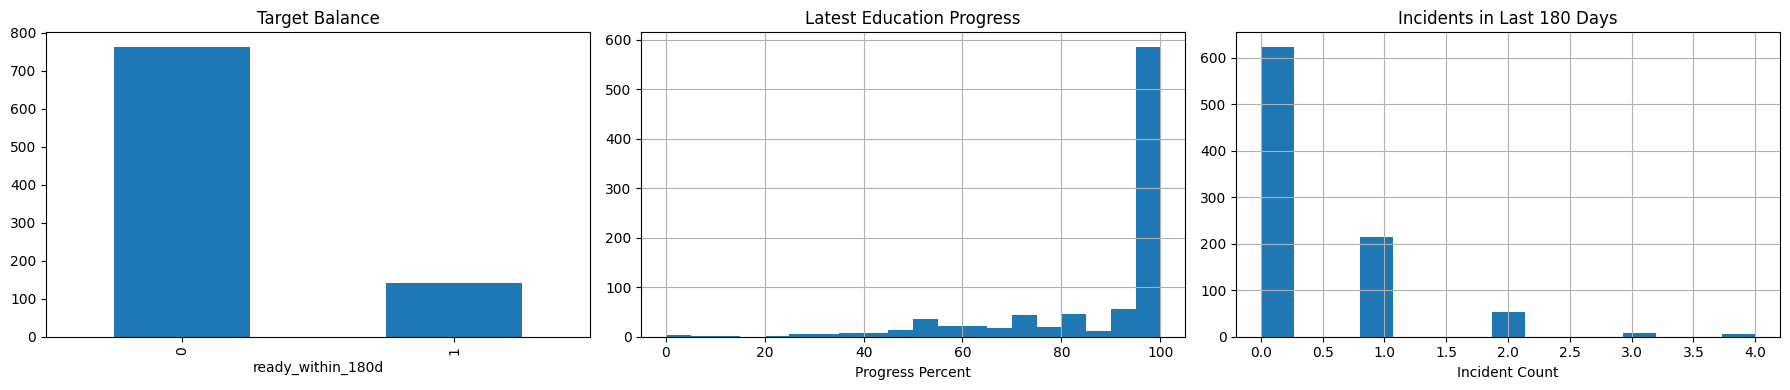

,feature,missing_fraction
0,safehouse_region,1.000000
1,safehouse_occupancy_rate,1.000000
2,avg_progress_last_180d,0.345133
3,avg_health_last_180d,0.345133
4,avg_attendance_last_180d,0.345133
5,reintegration_type_current,0.067478
6,group_session_share_last_90d,0.002212
7,avg_session_duration_last_90d,0.002212
8,hopeful_or_calm_end_share_last_90d,0.002212
9,resident_id,0.000000


In [ ]:
# Snapshot-level exploration

print("Residents represented:", snapshots["resident_id"].nunique())
print("Total snapshots:", len(snapshots))
print("Positive class rate:", snapshots["ready_within_180d"].mean().round(3))


# Create a figure with 3 subplots to visualize key distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: Distribution of the target variable (ready_within_180d)
snapshots["ready_within_180d"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Target Balance")
axes[0].set_xlabel("ready_within_180d")


# Plot 2: Distribution of latest education progress percentages
snapshots["latest_progress_percent"].hist(ax=axes[1], bins=20)
axes[1].set_title("Latest Education Progress")
axes[1].set_xlabel("Progress Percent")


# Plot 3: Distribution of incident counts in last 180 days
snapshots["incidents_last_180d"].hist(ax=axes[2], bins=15)
axes[2].set_title("Incidents in Last 180 Days")
axes[2].set_xlabel("Incident Count")

plt.tight_layout()
plt.show()

missing_pct = (
    snapshots.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
    .rename(columns={"index": "feature"})
)
missing_pct.head(15)

### Feature engineering choices

The engineered features in this pipeline reflect the case-management lifecycle:
- service intensity from counseling and home visits
- recent education progress and attendance
- recent health and wellbeing indicators
- active and achieved intervention plans
- incident severity and recency
- baseline resident and safehouse context

This is consistent with the assignment requirement to make feature engineering decisions explicit and grounded in the data, not hidden in a one-off script.

## 3. Modeling & Feature Selection

This section compares two predictive approaches:

1. **Feature-selected logistic regression**  
   - strong baseline
   - easier to interpret
   - uses one-hot encoding for categorical variables and model-based feature selection

2. **Random forest classifier**  
   - stronger nonlinear candidate
   - useful when interactions and thresholds matter

### Validation strategy
The dataset contains **multiple snapshots per resident**, so random row-level splitting would leak resident history across train and test data. To avoid that, this notebook uses **group-based splitting by resident**.

In [ ]:
# Prepare modeling dataset

model_df = snapshots.copy()

# Define columns to drop (not needed for modeling)
drop_cols = ["snapshot_date", "reintegration_type_current"]
# Create feature matrix X by dropping the target variable and unnecessary columns
X = model_df.drop(columns=["ready_within_180d"] + drop_cols)
y = model_df["ready_within_180d"].astype(int)
groups = model_df["resident_id"]

# Define which features are categorical (will need encoding)
categorical_features = [
    "safehouse_region",
    "case_status",
    "education_completion_status"
]

# Define which features are numeric (all others except IDs)
numeric_features = [
    col for col in X.columns
    if col not in categorical_features + ["resident_id", "safehouse_id"]
]

# Drop ID columns from feature matrix (they're not predictive features)
X = X.drop(columns=["resident_id", "safehouse_id"])

print("Model dataset shape:", X.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Model dataset shape: (904, 37)
Numeric features: 34
Categorical features: 3


In [ ]:
# Group-based train/test split

# Create GroupShuffleSplit to ensure residents don't appear in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# Create training and test feature matrices
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean().round(3))
print("Test positive rate:", y_test.mean().round(3))
print("Unique residents in train:", groups_train.nunique())
print("Unique residents in test:", groups_test.nunique())

Train shape: (653, 37)
Test shape: (251, 37)
Train positive rate: 0.181
Test positive rate: 0.092
Unique residents in train: 42
Unique residents in test: 14


In [ ]:
# Pipelines with dummy handling and feature selection where appropriate

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline for categorical features: impute with most frequent value, then one-hot encode
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applies different pipelines to different feature types
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

logit_feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ),
    threshold="median"
)


# Full logistic regression pipeline with preprocessing and feature selection
logit_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("feature_select", logit_feature_selector),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

# Random Forest pipeline with preprocessing (no feature selection needed)
rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ))
])

# Define cross-validation strategy (4-fold group-based)
cv = GroupKFold(n_splits=4)
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

logit_cv = cross_validate(
    logit_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

# Cross-validate the Random Forest pipeline
rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=None
)

cv_results = pd.DataFrame({
    "model": ["LogisticRegression+FeatureSelection", "RandomForest"],
    "cv_roc_auc_mean": [logit_cv["test_roc_auc"].mean(), rf_cv["test_roc_auc"].mean()],
    "cv_avg_precision_mean": [logit_cv["test_avg_precision"].mean(), rf_cv["test_avg_precision"].mean()],
    "cv_f1_mean": [logit_cv["test_f1"].mean(), rf_cv["test_f1"].mean()],
    "cv_precision_mean": [logit_cv["test_precision"].mean(), rf_cv["test_precision"].mean()],
    "cv_recall_mean": [logit_cv["test_recall"].mean(), rf_cv["test_recall"].mean()],
})

cv_results.sort_values("cv_roc_auc_mean", ascending=False)

,model,cv_roc_auc_mean,cv_avg_precision_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
1,RandomForest,0.862249,0.476347,0.263583,0.436438,0.193873
0,LogisticRegression+FeatureSelection,0.844931,0.488109,0.517801,0.406163,0.734386


In [21]:
# Light hyperparameter tuning for the random forest candidate

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions={
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 4, 6, 8],
        "model__min_samples_leaf": [1, 2, 4, 6],
        "model__max_features": ["sqrt", "log2", None]
    },
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_train, y_train, groups=groups_train)

best_rf_pipeline = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC AUC:", round(rf_search.best_score_, 4))

Best RF params: {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 4}
Best RF CV ROC AUC: 0.8711


## 4. Evaluation & Interpretation

This section evaluates the selected predictive model on a holdout test set that uses **different residents** than the training set.

That matters because the real question is not whether the model memorizes known residents. The question is whether the model generalizes well enough to support real decisions for the organization.

### Error costs in this context
- **False positive**: The model says a resident is likely ready for reintegration soon, but she is not.  
  This could cause staff to spend time preparing a reintegration review too early.

- **False negative**: The model says a resident is not likely ready soon, but she actually is.  
  This could delay beneficial planning, family engagement, or transition support.

In most case-management settings, false negatives may be more harmful because they can delay appropriate services or opportunities. That means recall can matter just as much as raw accuracy.

In [ ]:
# Fit final models and evaluate on the holdout test set

logit_pipeline.fit(X_train, y_train)
best_rf_pipeline.fit(X_train, y_train)

def evaluate_classifier(model, X_eval, y_eval, model_name):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    # Calculate all evaluation metrics
    metrics = {
        "model": model_name,
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "avg_precision": average_precision_score(y_eval, y_proba),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
    }

    return metrics, y_proba, y_pred


# Evaluate logistic regression on test se
logit_metrics, logit_proba, logit_pred = evaluate_classifier(logit_pipeline, X_test, y_test, "LogisticRegression+FeatureSelection")
rf_metrics, rf_proba, rf_pred = evaluate_classifier(best_rf_pipeline, X_test, y_test, "RandomForestTuned")

# Combine both models' results into a comparison dataframe and sort by ROC AUC
test_results = pd.DataFrame([logit_metrics, rf_metrics]).sort_values("roc_auc", ascending=False)
test_results

,model,roc_auc,avg_precision,f1,precision,recall
1,RandomForestTuned,0.962052,0.714964,0.592593,0.516129,0.695652
0,LogisticRegression+FeatureSelection,0.937071,0.433474,0.655738,0.526316,0.869565


In [ ]:
# Choose the better predictive model for operational deployment

if rf_metrics["roc_auc"] >= logit_metrics["roc_auc"]:
    final_model = best_rf_pipeline
    final_model_name = "RandomForestTuned"
    final_proba = rf_proba
    final_pred = rf_pred
else:
    final_model = logit_pipeline
    final_model_name = "LogisticRegression+FeatureSelection"
    final_proba = logit_proba
    final_pred = logit_pred

print("Selected final predictive model:", final_model_name)
print(classification_report(y_test, final_pred, zero_division=0))

# Create confusion matrix for the final model's predictions
cm = confusion_matrix(y_test, final_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)
cm_df

Selected final predictive model: RandomForestTuned
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       228
           1       0.52      0.70      0.59        23

    accuracy                           0.91       251
   macro avg       0.74      0.81      0.77       251
weighted avg       0.93      0.91      0.92       251



,Predicted 0,Predicted 1
Actual 0,213,15
Actual 1,7,16


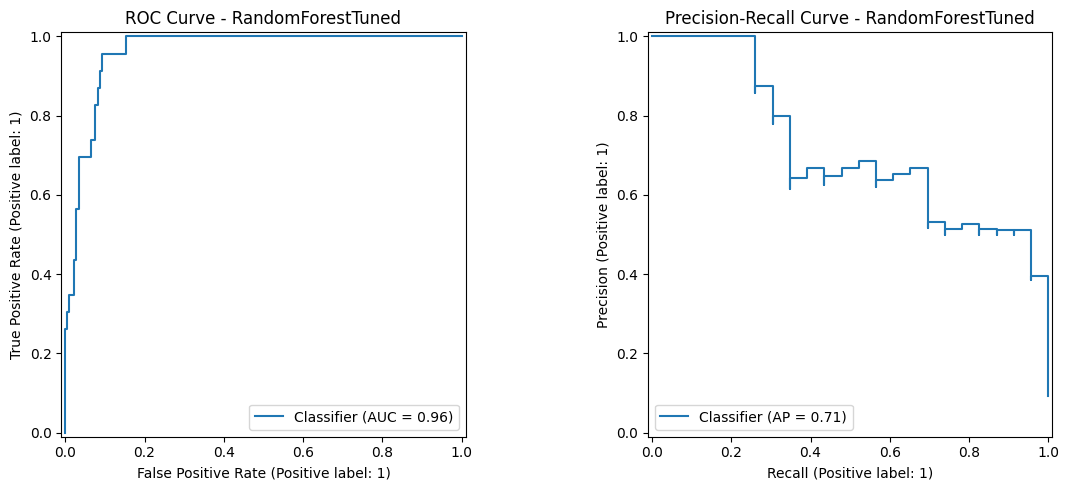

In [24]:
# Visual evaluation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[0])
axes[0].set_title(f"ROC Curve - {final_model_name}")

PrecisionRecallDisplay.from_predictions(y_test, final_proba, ax=axes[1])
axes[1].set_title(f"Precision-Recall Curve - {final_model_name}")

plt.tight_layout()
plt.show()

### Business interpretation

If this model performs reasonably well, the organization can use it as a **case review prioritization tool**, not as an automatic decision-maker.

Useful operational interpretations:
- residents with the highest scores should be reviewed first for reintegration planning
- low-scoring residents may need more counseling, incident stabilization, education support, or family follow-up before reintegration is considered
- leadership can aggregate these scores across safehouses to understand where reintegration progress appears strongest or weakest

## 5. Causal and Relationship Analysis

This section is deliberately separate from pure predictive evaluation.

The goal here is to answer:
- which features matter most?
- do the discovered relationships make theoretical sense?
- what does the model reveal about case structure?
- which conclusions are **associational** versus potentially **causal**?

This notebook does **not** claim that the model proves causation. The data is observational, synthetic, and operational in nature. That means the relationships can be useful for decision support without automatically being causal evidence.

In [25]:
# Permutation importance on the selected predictive model

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=SEED,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
3,case_status,0.434694,0.050001
5,age_years,0.015764,0.005082
4,days_since_admission,0.006725,0.003598
2,initial_risk_num,0.006178,0.002551
18,latest_progress_percent,0.004793,0.006065
14,home_visits_last_180d,0.003267,0.003196
8,process_sessions_last_180d,0.003038,0.001147
7,process_sessions_last_90d,0.002822,0.001786
11,hopeful_or_calm_end_share_last_90d,0.002161,0.001137
6,process_sessions_last_30d,0.002148,0.001262


In [ ]:
# Companion explanatory model
# This is still an association model, not a causal proof.

explanatory_features = [
    "days_since_admission",
    "initial_risk_num",
    "process_sessions_last_90d",
    "home_visits_last_180d",
    "latest_progress_percent",
    "avg_attendance_last_180d",
    "latest_general_health_score",
    "active_plans_count",
    "reintegration_plan_count",
    "incidents_last_180d",
    "high_severity_incidents_last_180d",
    "runaway_attempts_last_180d",
    "self_harm_last_180d",
    "safehouse_region",
    "education_completion_status",
]

# Separate numeric and categorical features for preprocessing
# Numeric features: all explanatory features except the two categorical ones
num_explain = [c for c in explanatory_features if c not in ["safehouse_region", "education_completion_status"]]
cat_explain = ["safehouse_region", "education_completion_status"]

# Preprocessor for the explanatory model (same structure as main model)
explain_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_explain),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_explain)
    ]
)

explain_model = Pipeline(steps=[
    ("prep", explain_preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=SEED
    ))
])

# Explanatory model: Simple logistic regression with balanced class weights
explain_model.fit(X_train[explanatory_features], y_train)

# Extract feature names after preprocessing (includes one-hot encoded categorical features)
feature_names = explain_model.named_steps["prep"].get_feature_names_out()
coef_values = explain_model.named_steps["model"].coef_[0]

# Create a dataframe of features and their coefficients
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef_values,
    "abs_coefficient": np.abs(coef_values)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coefficient
12,num__self_harm_last_180d,-0.745801,0.745801
1,num__initial_risk_num,-0.559393,0.559393
10,num__high_severity_incidents_last_180d,0.483093,0.483093
3,num__home_visits_last_180d,0.365662,0.365662
2,num__process_sessions_last_90d,0.317325,0.317325
11,num__runaway_attempts_last_180d,-0.305285,0.305285
15,cat__education_completion_status_InProgress,0.276514,0.276514
16,cat__education_completion_status_NotStarted,-0.257610,0.257610
4,num__latest_progress_percent,0.167266,0.167266
7,num__active_plans_count,0.162314,0.162314


### Relationship analysis write-up

When you review the feature importance and coefficient outputs above, look for patterns such as:
- whether stronger recent education progress is associated with higher readiness
- whether recent high-severity incidents are associated with lower readiness
- whether reintegration-related plans and case conferences are associated with higher readiness
- whether process sessions and home visits appear supportive or simply markers of higher-need cases

Important caution:
- a feature can be predictive **because staff respond to need**, not because the feature causes the outcome
- for example, more process sessions might correlate with both higher or lower readiness depending on whether they reflect progress or crisis response
- this is why predictive importance and causal interpretation are not the same thing

In the final report, be explicit:
- **what the model predicts**
- **what the model suggests**
- **what the model does not prove**

## 6. Deployment Notes

Following the textbook deployment pattern, the web application should **read predictions**, not retrain the model during page load.

### Proposed integration
This pipeline fits naturally into the **Admin Dashboard** or a dedicated **Reintegration Review Queue** page.

### Suggested UI behavior
The app can display:
- resident ID or internal code
- safehouse
- readiness probability
- predicted ready / not ready flag
- recent incidents
- latest education progress
- latest health score
- recommended next step

### Recommended backend contract
The ML pipeline can write a prediction table or CSV with fields like:
- `resident_id`
- `snapshot_date`
- `reintegration_readiness_probability`
- `predicted_ready_within_180d`
- `model_version`
- `prediction_timestamp`

Then the app simply queries and renders those rows. That keeps the deployment simple and aligned with the course guidance that the app should consume model outputs, not run training logic itself.

In [ ]:
# Build a live scoring dataset for active residents as of the analysis cutoff.
# This is the kind of output the web app would read.

def build_live_inference_rows(
    residents_df,
    process_df,
    visit_df,
    edu_df,
    health_df,
    plans_df,
    incidents_df,
    as_of_date
):# Filter to only active residents (admitted and not yet closed, or closed after as_of_date)
    
    rows = []

    active_residents = residents_df[
        residents_df["date_of_admission"].notna()
        & (
            residents_df["date_closed"].isna()
            | (residents_df["date_closed"] > as_of_date)
        )
    ].copy()
 # Loop through each active resident
    for _, resident in active_residents.iterrows():
        resident_id = resident["resident_id"]
        snapshot_date = as_of_date

        # Get the most recent education and health records before snapshot date
        latest_edu = get_latest_row(edu_df, resident_id, "record_date", snapshot_date)
        latest_health = get_latest_row(health_df, resident_id, "record_date", snapshot_date)

        process_90 = process_df[
            (process_df["resident_id"] == resident_id)
            & (process_df["session_date"] > snapshot_date - pd.Timedelta(days=90))
            & (process_df["session_date"] <= snapshot_date)
        ]

        visits_180 = visit_df[
            (visit_df["resident_id"] == resident_id)
            & (visit_df["visit_date"] > snapshot_date - pd.Timedelta(days=180))
            & (visit_df["visit_date"] <= snapshot_date)
        ]

        incidents_180 = incidents_df[
            (incidents_df["resident_id"] == resident_id)
            & (incidents_df["incident_date"] > snapshot_date - pd.Timedelta(days=180))
            & (incidents_df["incident_date"] <= snapshot_date)
        ]

 # Get all intervention plans created on or before snapshot date
        
        plans_hist = plans_df[
            (plans_df["resident_id"] == resident_id)
            & (plans_df["created_at"] <= snapshot_date)
        ]
# Build the feature row for this resident
        
        row = {
            "resident_id": resident_id,
            "snapshot_date": snapshot_date,
            "safehouse_region": resident.get("region"),
            "safehouse_occupancy_rate": resident.get("occupancy_rate"),
            "initial_risk_num": resident.get("initial_risk_num"),
            "case_status": resident.get("case_status"),
            "days_since_admission": (snapshot_date - resident["date_of_admission"]).days if pd.notna(resident["date_of_admission"]) else np.nan,
            "age_years": ((snapshot_date - resident["date_of_birth"]).days / 365.25) if pd.notna(resident.get("date_of_birth")) else np.nan,
            "process_sessions_last_30d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 30),
            "process_sessions_last_90d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 90),
            "process_sessions_last_180d": get_recent_count(process_df, resident_id, "session_date", snapshot_date, 180),
            "avg_session_duration_last_90d": process_90["session_duration_minutes"].mean() if not process_90.empty else np.nan,
            "group_session_share_last_90d": process_90["session_type"].eq("Group").mean() if not process_90.empty else np.nan,
            "hopeful_or_calm_end_share_last_90d": (
                process_90["emotional_state_end"].isin(["Hopeful", "Calm", "Happy"]).mean()
                if not process_90.empty else np.nan
            ),
            "home_visits_last_30d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 30),
            "home_visits_last_90d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 90),
            "home_visits_last_180d": get_recent_count(visit_df, resident_id, "visit_date", snapshot_date, 180),
            "reintegration_assessments_last_180d": int(visits_180["visit_type"].eq("Reintegration Assessment").sum()),
            "post_placement_monitoring_last_180d": int(visits_180["visit_type"].eq("Post-Placement Monitoring").sum()),
            "latest_attendance_rate": latest_edu["attendance_rate"] if latest_edu is not None else np.nan,
            "latest_progress_percent": latest_edu["progress_percent"] if latest_edu is not None else np.nan,
            "education_completion_status": latest_edu["completion_status"] if latest_edu is not None else np.nan,
            "avg_attendance_last_180d": get_mean_recent(edu_df, resident_id, "record_date", "attendance_rate", snapshot_date, 180),
            "avg_progress_last_180d": get_mean_recent(edu_df, resident_id, "record_date", "progress_percent", snapshot_date, 180),
            "latest_general_health_score": latest_health["general_health_score"] if latest_health is not None else np.nan,
            "latest_sleep_quality_score": latest_health["sleep_quality_score"] if latest_health is not None else np.nan,
            "latest_energy_level_score": latest_health["energy_level_score"] if latest_health is not None else np.nan,
            "avg_health_last_180d": get_mean_recent(health_df, resident_id, "record_date", "general_health_score", snapshot_date, 180),
            "active_plans_count": int(plans_hist["status"].isin(["Open", "In Progress", "On Hold"]).sum()),
            "achieved_plans_count": int(plans_hist["status"].eq("Achieved").sum()),
            "reintegration_plan_count": int(plans_hist["plan_category"].eq("Reintegration").sum()),
            "recent_case_conferences_last_180d": int(
                plans_hist["case_conference_date"].between(
                    snapshot_date - pd.Timedelta(days=180),
                    snapshot_date,
                    inclusive="both"
                ).sum()
            ),
            "incidents_last_30d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 30),
            "incidents_last_90d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 90),
            "incidents_last_180d": get_recent_count(incidents_df, resident_id, "incident_date", snapshot_date, 180),
            "high_severity_incidents_last_180d": int(incidents_180["severity"].eq("High").sum()),
            "runaway_attempts_last_180d": int(incidents_180["incident_type"].eq("RunawayAttempt").sum()),
            "self_harm_last_180d": int(incidents_180["incident_type"].eq("SelfHarm").sum()),
            "follow_up_required_incidents_last_180d": int(incidents_180["follow_up_required"].fillna(False).astype(bool).sum()),
        }

        rows.append(row)

    return pd.DataFrame(rows)


# Build live scoring dataframe using current residents and data up to ANALYSIS_CUTOFF
live_scoring_df = build_live_inference_rows(
    residents_df=residents,
    process_df=process_recordings,
    visit_df=home_visitations,
    edu_df=education_records,
    health_df=health_records,
    plans_df=intervention_plans,
    incidents_df=incident_reports,
    as_of_date=ANALYSIS_CUTOFF
)
# Generate predictions using the final trained model

live_scoring_df["reintegration_readiness_probability"] = final_model.predict_proba(live_scoring_df[X.columns])[:, 1]
live_scoring_df["predicted_ready_within_180d"] = (live_scoring_df["reintegration_readiness_probability"] >= 0.50).astype(int)
live_scoring_df["prediction_timestamp"] = pd.Timestamp.now()
live_scoring_df["model_name"] = final_model_name

live_queue = live_scoring_df.sort_values("reintegration_readiness_probability", ascending=False).copy()

output_path = OUTPUT_DIR / "resident_reintegration_queue.csv"
live_queue.to_csv(output_path, index=False)

# Display a preview of the live queue with key columns

print(f"Saved live scoring output to: {output_path.resolve()}")
live_queue[[
    "resident_id",
    "safehouse_region",
    "reintegration_readiness_probability",
    "predicted_ready_within_180d",
    "latest_progress_percent",
    "latest_general_health_score",
    "incidents_last_180d",
    "high_severity_incidents_last_180d"
]].head(15)

Saved live scoring output to: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\generated_outputs\resident_reintegration_queue.csv


,resident_id,safehouse_region,reintegration_readiness_probability,predicted_ready_within_180d,latest_progress_percent,latest_general_health_score,incidents_last_180d,high_severity_incidents_last_180d
4,7,None,0.285359,0,100.0,3.24,0,0
26,53,None,0.229931,0,100.0,3.52,1,0
11,17,None,0.213572,0,100.0,3.48,1,0
16,32,None,0.211268,0,100.0,3.23,1,0
13,21,None,0.205383,0,100.0,3.31,0,0
10,16,None,0.197599,0,100.0,3.32,0,0
27,55,None,0.187569,0,98.3,3.46,0,0
24,49,None,0.183167,0,100.0,3.18,0,0
19,40,None,0.172219,0,100.0,3.94,0,0
21,42,None,0.170569,0,100.0,3.06,0,0


## Final Notes

This notebook is designed to be:
- executable top to bottom
- explicit about the prediction vs. explanation distinction
- aligned with the textbook chapters on preparation, classification, evaluation, feature selection, and deployment
- useful for a staff-facing dashboard or queue in the web application

Before final submission, update any wording to match your team’s actual UI, repo paths, and deployment implementation.